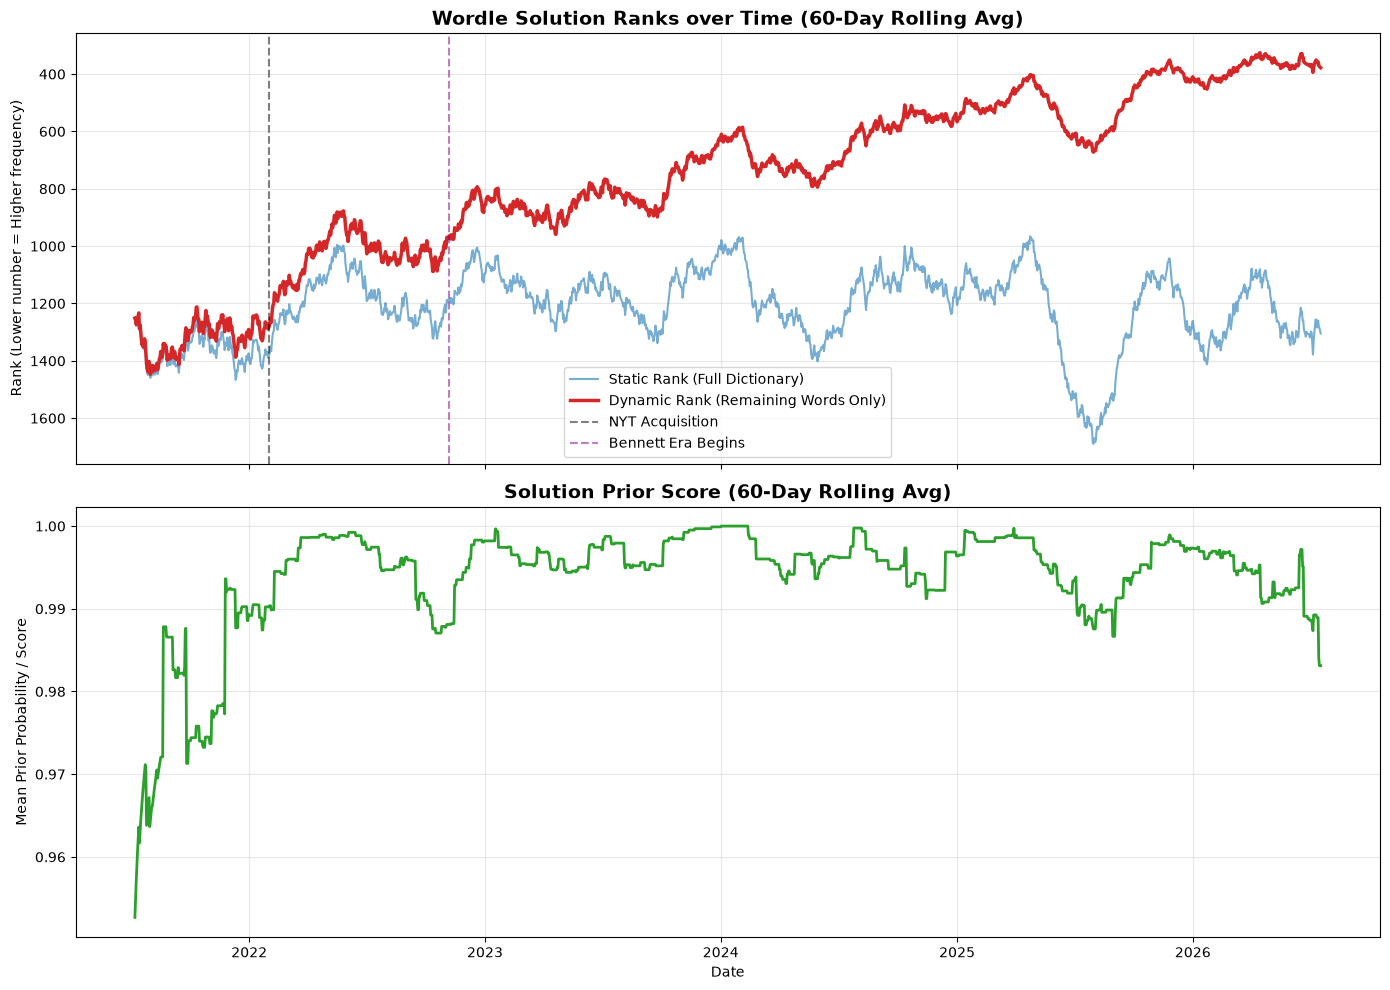

=== WORDLE TREND INSIGHTS (GAMES 0-1291) ===
Total Games Processed: 1856
Initial 200 Games Avg Dynamic Rank: 1321.3
Final 200 Games Avg Dynamic Rank:   375.5
Dictionary Deflation: 1856 highest-probability words permanently removed.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Paths and Data Ingestion
DATA_DIR = os.path.join("..", "data")
PRIORS_PATH = os.path.join(DATA_DIR, "unseen_cleaned_priors.csv")
ANSWERS_PATH = os.path.join(DATA_DIR, "past_answers.csv")

# 2. Load and Filter (Strict 2025 Hold-out)
answers_df = pd.read_csv(ANSWERS_PATH)
answers_df = answers_df[answers_df['game_num'] <= 1855].copy()
answers_df = answers_df.sort_values('game_num').reset_index(drop=True)

priors_df = pd.read_csv(PRIORS_PATH)
priors_df['word'] = priors_df['word'].astype(str).str.strip().str.lower()
priors_dict = dict(zip(priors_df['word'], priors_df['prior']))

# 3. Establish Ranking Mechanics
# Sort words by prior (descending) to serve as our master frequency pool
priors_df = priors_df.sort_values('prior', ascending=False)
all_words = priors_df['word'].tolist()

static_ranks = {word: rank for rank, word in enumerate(all_words, start=1)}
dynamic_pool = all_words.copy() # Will shrink as words are used

results = []
for _, row in answers_df.iterrows():
    ans = row['solution'].strip().lower()
    
    static_rank = static_ranks.get(ans, np.nan)
    prior_score = priors_dict.get(ans, 0.0)
    
    # Calculate Dynamic Rank, then exhaust the word
    if ans in dynamic_pool:
        dynamic_rank = dynamic_pool.index(ans) + 1
        dynamic_pool.remove(ans)
    else:
        dynamic_rank = np.nan
        
    results.append({
        'game_num': row['game_num'],
        'date': pd.to_datetime(row['date']),
        'solution': ans,
        'prior_score': prior_score,
        'static_rank': static_rank,
        'dynamic_rank': dynamic_rank,
        'pool_size': len(dynamic_pool)
    })

res_df = pd.DataFrame(results)

# 4. Visualization: Rolling Trends
window = 60 # 60-day rolling window smooths out day-to-day variance
res_df['rolling_static'] = res_df['static_rank'].rolling(window=window, min_periods=20).mean()
res_df['rolling_dynamic'] = res_df['dynamic_rank'].rolling(window=window, min_periods=20).mean()
res_df['rolling_prior'] = res_df['prior_score'].rolling(window=window, min_periods=20).mean()

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot A: The Rank Gap
axs[0].plot(res_df['date'], res_df['rolling_static'], label='Static Rank (Full Dictionary)', color='tab:blue', alpha=0.6)
axs[0].plot(res_df['date'], res_df['rolling_dynamic'], label='Dynamic Rank (Remaining Words Only)', color='tab:red', linewidth=2.5)

# Editorial Milestones
nyt_buy = pd.to_datetime('2022-02-01') # NYT Acquisition
tracy_b = pd.to_datetime('2022-11-07') # Tracy Bennett begins as Editor
axs[0].axvline(nyt_buy, color='k', linestyle='--', alpha=0.5, label='NYT Acquisition')
axs[0].axvline(tracy_b, color='purple', linestyle='--', alpha=0.5, label='Bennett Era Begins')

axs[0].invert_yaxis() # Rank 1 at the top
axs[0].set_title(f"Wordle Solution Ranks over Time ({window}-Day Rolling Avg)", fontsize=14, fontweight='bold')
axs[0].set_ylabel("Rank (Lower number = Higher frequency)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot B: Prior Score Decay
axs[1].plot(res_df['date'], res_df['rolling_prior'], color='tab:green', linewidth=2)
axs[1].set_title(f"Solution Prior Score ({window}-Day Rolling Avg)", fontsize=14, fontweight='bold')
axs[1].set_ylabel("Mean Prior Probability / Score")
axs[1].set_xlabel("Date")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Diagnostic Output
print("=== WORDLE TREND INSIGHTS (GAMES 0-1291) ===")
print(f"Total Games Processed: {len(res_df)}")
print(f"Initial 200 Games Avg Dynamic Rank: {res_df.head(200)['dynamic_rank'].mean():.1f}")
print(f"Final 200 Games Avg Dynamic Rank:   {res_df.tail(200)['dynamic_rank'].mean():.1f}")
print(f"Dictionary Deflation: {len(res_df)} highest-probability words permanently removed.")

C:\Users\edwar\AppData\Local\Temp\ipykernel_26172\3415426898.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='era', y='static_rank', data=res_df, ax=axs[1], palette='pastel', inner='quartile')


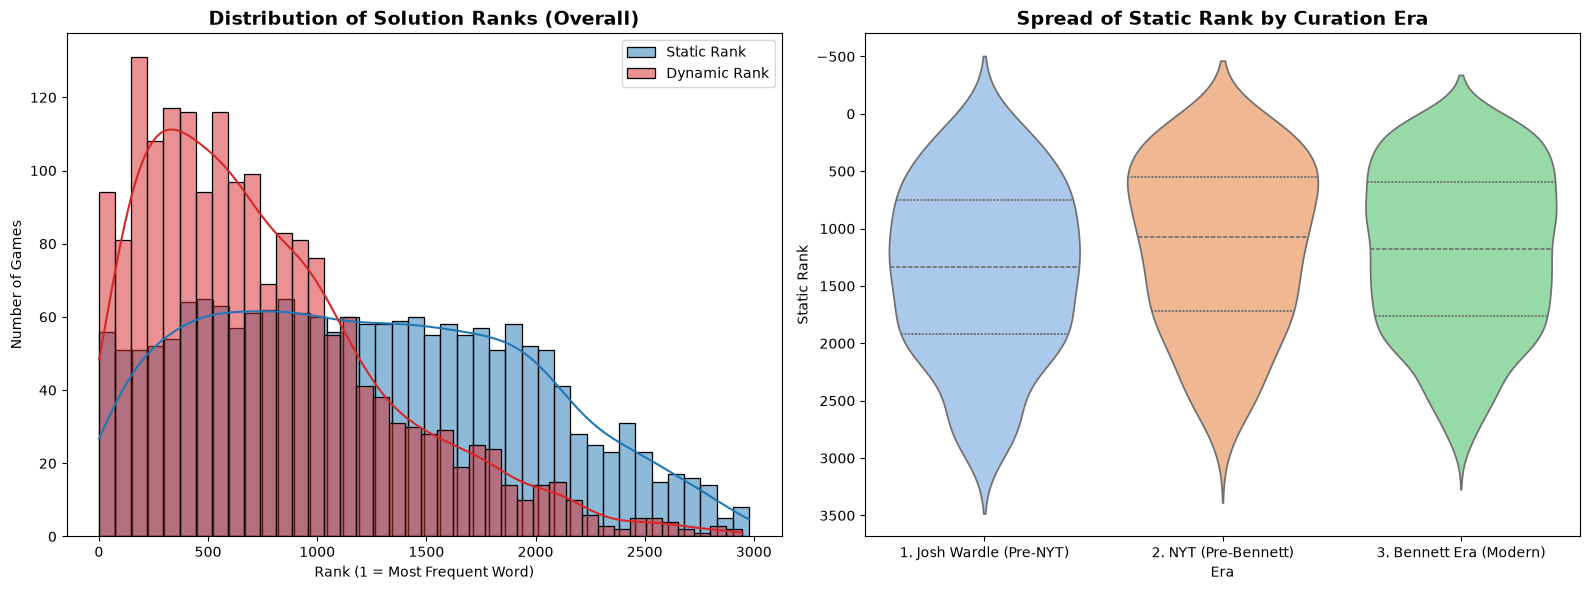

=== STATISTICAL SPREAD OF STATIC RANK ===
Overall Median Rank: 1181
Overall Middle 50% (IQR): Ranks 607 to 1778
Total Spread (Middle 50% Width): 1172 ranks

=== SPREAD BY ERA (MIDDLE 50% IQR) ===
1. Josh Wardle (Pre-NYT):
  -> Median: 1335
  -> IQR: Ranks 752 to 1917 (Width: 1166)
2. NYT (Pre-Bennett):
  -> Median: 1075
  -> IQR: Ranks 550 to 1720 (Width: 1169)
3. Bennett Era (Modern):
  -> Median: 1174
  -> IQR: Ranks 594 to 1765 (Width: 1170)


In [3]:
import seaborn as sns

# 1. Define Curation Eras to see if the spread has changed over time
def get_era(date):
    if date < pd.to_datetime('2022-02-01'):
        return '1. Josh Wardle (Pre-NYT)'
    elif date < pd.to_datetime('2022-11-07'):
        return '2. NYT (Pre-Bennett)'
    else:
        return '3. Bennett Era (Modern)'

res_df['era'] = res_df['date'].apply(get_era)

# 2. Setup Figure
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Overall Histogram/KDE of Ranks
sns.histplot(res_df['static_rank'], bins=40, color='tab:blue', alpha=0.5, label='Static Rank', kde=True, ax=axs[0])
sns.histplot(res_df['dynamic_rank'], bins=40, color='tab:red', alpha=0.5, label='Dynamic Rank', kde=True, ax=axs[0])
axs[0].set_title("Distribution of Solution Ranks (Overall)", fontsize=14, fontweight='bold')
axs[0].set_xlabel("Rank (1 = Most Frequent Word)")
axs[0].set_ylabel("Number of Games")
axs[0].legend()

# Plot B: Violin Plot of Static Rank by Era (Shows the density and spread)
sns.violinplot(x='era', y='static_rank', data=res_df, ax=axs[1], palette='pastel', inner='quartile')
axs[1].set_title("Spread of Static Rank by Curation Era", fontsize=14, fontweight='bold')
axs[1].set_ylabel("Static Rank")
axs[1].set_xlabel("Era")
axs[1].invert_yaxis() # Keep Rank 1 at the top

plt.tight_layout()
plt.show()

# 3. Print Statistical Spread (Checking your 1200-1500 hypothesis)
print("=== STATISTICAL SPREAD OF STATIC RANK ===")
overall_median = res_df['static_rank'].median()
overall_q1 = res_df['static_rank'].quantile(0.25)
overall_q3 = res_df['static_rank'].quantile(0.75)
print(f"Overall Median Rank: {overall_median:.0f}")
print(f"Overall Middle 50% (IQR): Ranks {overall_q1:.0f} to {overall_q3:.0f}")
print(f"Total Spread (Middle 50% Width): {overall_q3 - overall_q1:.0f} ranks\n")

print("=== SPREAD BY ERA (MIDDLE 50% IQR) ===")
for era in sorted(res_df['era'].unique()):
    era_df = res_df[res_df['era'] == era]
    q1 = era_df['static_rank'].quantile(0.25)
    q3 = era_df['static_rank'].quantile(0.75)
    print(f"{era}:")
    print(f"  -> Median: {era_df['static_rank'].median():.0f}")
    print(f"  -> IQR: Ranks {q1:.0f} to {q3:.0f} (Width: {q3 - q1:.0f})")

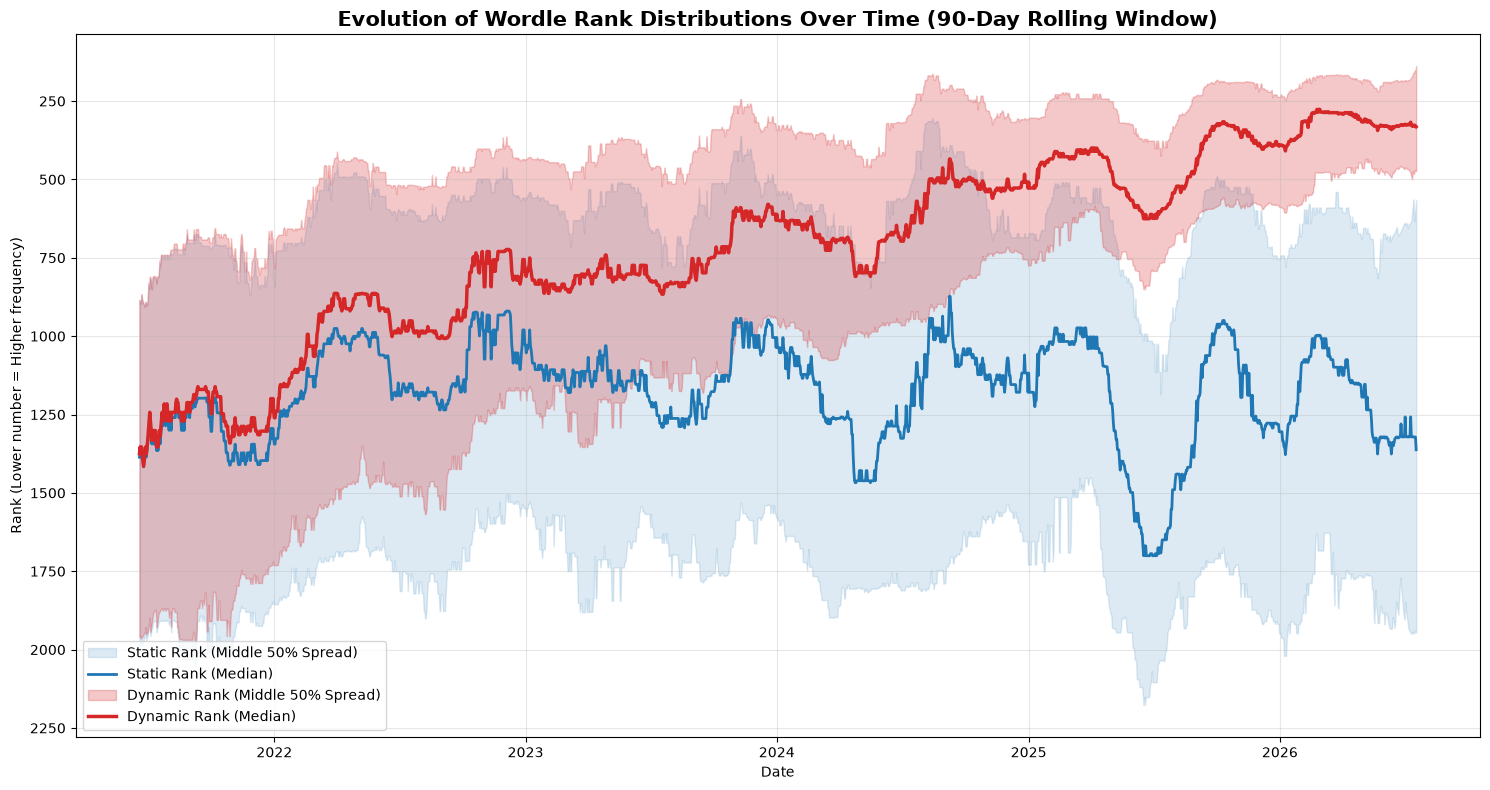

=== DISTRIBUTION SPREAD OVER TIME ===
Average Static Spread (First 100 valid games): 1191 ranks
Average Static Spread (Last 100 valid games):  1177 ranks
-> The static vocabulary spread is NARROWING (Editors are tightening their bounds).


In [4]:
import matplotlib.dates as mdates

# 1. Define the rolling window for our distribution
window_size = 90 # 90-day window to capture the spread smoothly

# 2. Calculate rolling quantiles for Static Rank
res_df['static_p25'] = res_df['static_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.25)
res_df['static_p50'] = res_df['static_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.50)
res_df['static_p75'] = res_df['static_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.75)

# 3. Calculate rolling quantiles for Dynamic Rank
res_df['dynamic_p25'] = res_df['dynamic_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.25)
res_df['dynamic_p50'] = res_df['dynamic_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.50)
res_df['dynamic_p75'] = res_df['dynamic_rank'].rolling(window_size, center=True, min_periods=30).quantile(0.75)

# 4. Plot the shifting distributions
fig, ax = plt.subplots(figsize=(15, 8))

# Static Rank Envelope
ax.fill_between(res_df['date'], res_df['static_p25'], res_df['static_p75'], 
                color='tab:blue', alpha=0.15, label='Static Rank (Middle 50% Spread)')
ax.plot(res_df['date'], res_df['static_p50'], color='tab:blue', linewidth=2, label='Static Rank (Median)')

# Dynamic Rank Envelope
ax.fill_between(res_df['date'], res_df['dynamic_p25'], res_df['dynamic_p75'], 
                color='tab:red', alpha=0.25, label='Dynamic Rank (Middle 50% Spread)')
ax.plot(res_df['date'], res_df['dynamic_p50'], color='tab:red', linewidth=2.5, label='Dynamic Rank (Median)')

# Formatting
ax.invert_yaxis() # Rank 1 at the top
ax.set_title("Evolution of Wordle Rank Distributions Over Time (90-Day Rolling Window)", fontsize=15, fontweight='bold')
ax.set_ylabel("Rank (Lower number = Higher frequency)")
ax.set_xlabel("Date")
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

# Add a metric for "Spread Width" to see if the game is getting more erratic
res_df['static_spread'] = res_df['static_p75'] - res_df['static_p25']
res_df['dynamic_spread'] = res_df['dynamic_p75'] - res_df['dynamic_p25']

plt.tight_layout()
plt.show()

# 5. Output Diagnostic Insights on the Spread
print("=== DISTRIBUTION SPREAD OVER TIME ===")
first_100_spread = res_df['static_spread'].dropna().head(100).mean()
last_100_spread = res_df['static_spread'].dropna().tail(100).mean()

print(f"Average Static Spread (First 100 valid games): {first_100_spread:.0f} ranks")
print(f"Average Static Spread (Last 100 valid games):  {last_100_spread:.0f} ranks")
if last_100_spread > first_100_spread:
    print("-> The static vocabulary spread is WIDENING (Editors are utilizing more variance).")
else:
    print("-> The static vocabulary spread is NARROWING (Editors are tightening their bounds).")

Running Robust Forward-Looking Simulation (Adaptive vs. Static Agent)...


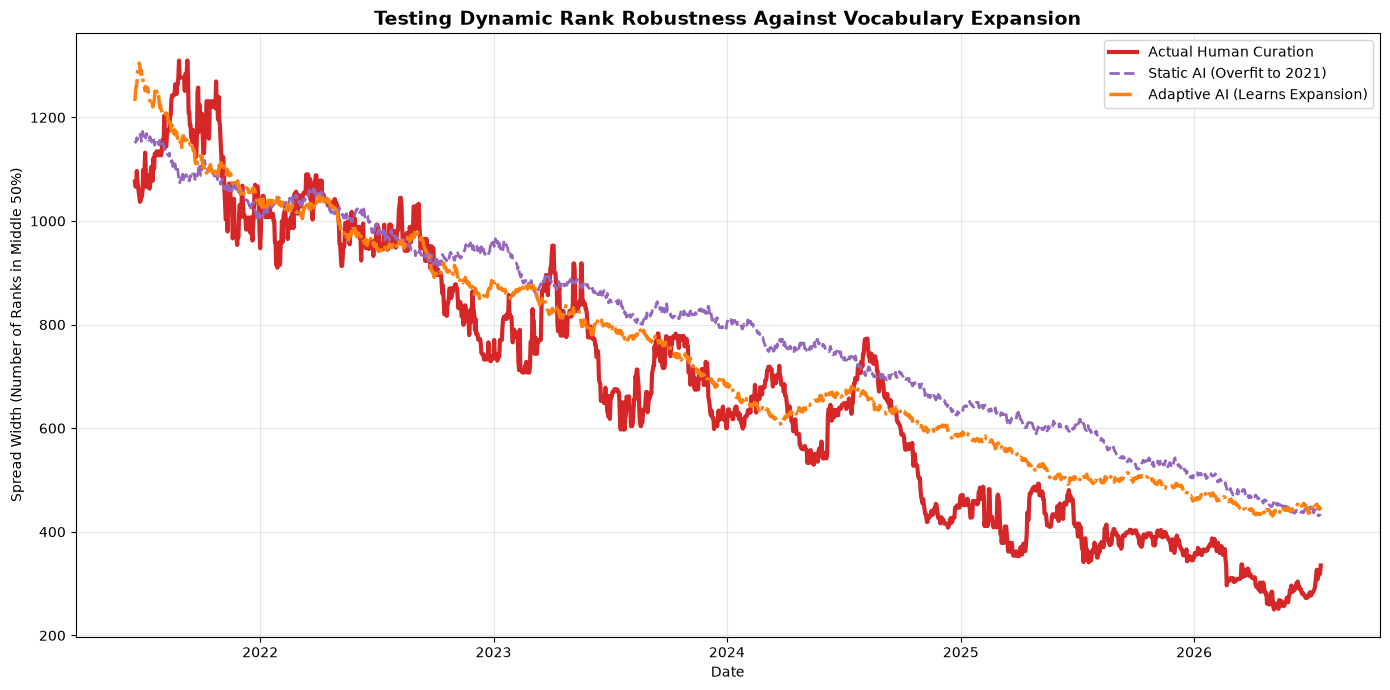

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

print("Running Robust Forward-Looking Simulation (Adaptive vs. Static Agent)...")

n_simulations = 20 # Keep low for performance
window_size = 90
total_games = len(res_df)

static_spreads = []
adaptive_spreads = []

# 1. Train the Static Agent ONCE (Overfitting to the past)
wardle_games = res_df.head(200)
static_kde = gaussian_kde(wardle_games['static_rank'].dropna())
master_ranks = np.arange(1, len(all_words) + 1)

static_probs = np.clip(static_kde(master_ranks), 1e-10, None)
static_probs /= static_probs.sum()

for i in range(n_simulations):
    np.random.seed(100 + i)
    
    # --- SIMULATION A: STATIC AGENT ---
    sim_choices_static = np.random.choice(a=all_words, size=total_games, replace=False, p=static_probs)
    
    dynamic_pool_static = all_words.copy()
    dynamic_ranks_static = []
    for ans in sim_choices_static:
        dynamic_ranks_static.append(dynamic_pool_static.index(ans) + 1)
        dynamic_pool_static.remove(ans)
        
    s_series = pd.Series(dynamic_ranks_static)
    s_p25 = s_series.rolling(window=window_size, center=True, min_periods=30).quantile(0.25)
    s_p75 = s_series.rolling(window=window_size, center=True, min_periods=30).quantile(0.75)
    static_spreads.append(s_p75 - s_p25)

    # --- SIMULATION B: ADAPTIVE AGENT (Rolling Distribution) ---
    dynamic_pool_adaptive = all_words.copy()
    dynamic_ranks_adaptive = []
    
    # The Adaptive Agent updates its preferences in chunks (every 100 games)
    # to mirror the NYT's changing/expanding vocabulary bounds.
    chunk_size = 100
    adaptive_choices = []
    
    for chunk_start in range(0, total_games, chunk_size):
        chunk_end = min(chunk_start + chunk_size, total_games)
        
        # Look at the actual human curation up to this point to learn the CURRENT vocabulary bounds
        current_history = res_df.iloc[max(0, chunk_start-200):chunk_end]
        if len(current_history) < 20: 
            current_probs = static_probs # Fallback for very early games
        else:
            adaptive_kde = gaussian_kde(current_history['static_rank'].dropna())
            current_probs = np.clip(adaptive_kde(master_ranks), 1e-10, None)
            
            # Zero out words already used by this agent so it doesn't try to pick them again
            for used_word in adaptive_choices:
                word_idx = all_words.index(used_word)
                current_probs[word_idx] = 0.0
                
            if current_probs.sum() > 0:
                current_probs /= current_probs.sum()
            else:
                current_probs = static_probs # Fallback if math breaks
                
        # Draw for this chunk
        chunk_choices = np.random.choice(a=all_words, size=(chunk_end - chunk_start), replace=False, p=current_probs)
        adaptive_choices.extend(chunk_choices)
        
        for ans in chunk_choices:
            dynamic_ranks_adaptive.append(dynamic_pool_adaptive.index(ans) + 1)
            dynamic_pool_adaptive.remove(ans)
            
    a_series = pd.Series(dynamic_ranks_adaptive)
    a_p25 = a_series.rolling(window=window_size, center=True, min_periods=30).quantile(0.25)
    a_p75 = a_series.rolling(window=window_size, center=True, min_periods=30).quantile(0.75)
    adaptive_spreads.append(a_p75 - a_p25)

# 2. Average the simulations
mean_static_spread = pd.concat(static_spreads, axis=1).mean(axis=1)
mean_adaptive_spread = pd.concat(adaptive_spreads, axis=1).mean(axis=1)

# 3. Plot Actual vs. Static vs. Adaptive
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(res_df['date'], res_df['dynamic_spread'], color='tab:red', linewidth=3, label='Actual Human Curation')
ax.plot(res_df['date'], mean_static_spread, color='tab:purple', linestyle='--', linewidth=2, label='Static AI (Overfit to 2021)')
ax.plot(res_df['date'], mean_adaptive_spread, color='tab:orange', linestyle='-.', linewidth=2.5, label='Adaptive AI (Learns Expansion)')

ax.set_title("Testing Dynamic Rank Robustness Against Vocabulary Expansion", fontsize=14, fontweight='bold')
ax.set_ylabel("Spread Width (Number of Ranks in Middle 50%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

# 1. Load priors directly from priors_4500.csv
df_priors = pd.read_csv('../data/priors_4500.csv', header=None)

# Detect and skip header row if present
try:
    float(df_priors.iloc[0, 1])
except (ValueError, TypeError):
    df_priors = pd.read_csv('../data/priors_4500.csv')

words = df_priors.iloc[:, 0].astype(str).str.strip().str.lower()
priors = pd.to_numeric(df_priors.iloc[:, 1], errors='coerce').fillna(0.0)
s_priors = pd.Series(priors.values, index=words.values)

# 2. Filter for non-zero valid guesses
valid_priors = s_priors[s_priors > 1e-9]

# 3. Categorize into your three tiers
count_ones = np.isclose(valid_priors, 1.0).sum()
count_small = (valid_priors <= 0.01).sum()
count_mid = len(valid_priors) - count_ones - count_small

# 4. Display the rundown
print("=" * 45)
print("       CURRENT PRIOR LIST DIAGNOSTIC       ")
print("=" * 45)
print(f"Total Valid Guesses (Non-Zero): {len(valid_priors):,}")
print("-" * 45)
print(f"• Frequency Floor (p == 1.0):    {count_ones:,} words")
print(f"• Small Tier (p <= 0.01):        {count_small:,} words")
print(f"• Middle Tier (0.01 < p < 1.0):   {count_mid:,} words")
print("=" * 45)

# Value counts of the most common distinct prior values
print("\nTop 10 Most Common Prior Values:")
print(valid_priors.value_counts().head(10).to_string())

       CURRENT PRIOR LIST DIAGNOSTIC       
Total Valid Guesses (Non-Zero): 4,500
---------------------------------------------
• Frequency Floor (p == 1.0):    2,110 words
• Small Tier (p <= 0.01):        1,519 words
• Middle Tier (0.01 < p < 1.0):   871 words

Top 10 Most Common Prior Values:
1.000000    2110
0.003896    1518
0.829263      11
0.911774      10
0.721877      10
0.816387       9
0.638004       8
0.835053       8
0.885892       8
0.031973       7


Total 1.0 Tier Words: 2110
Total Solutions from 1.0 Tier (2021-2026): 1629 / 1856


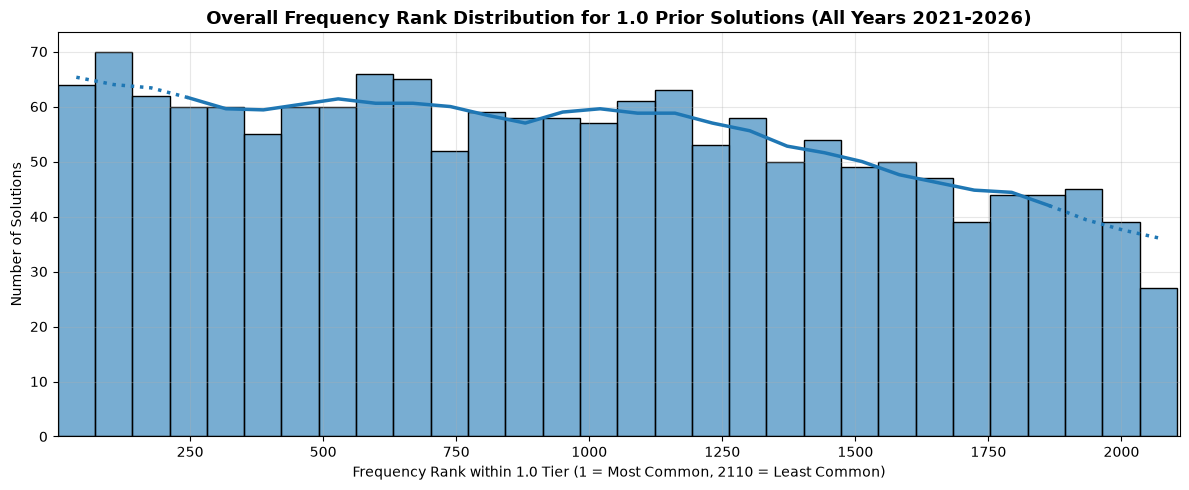

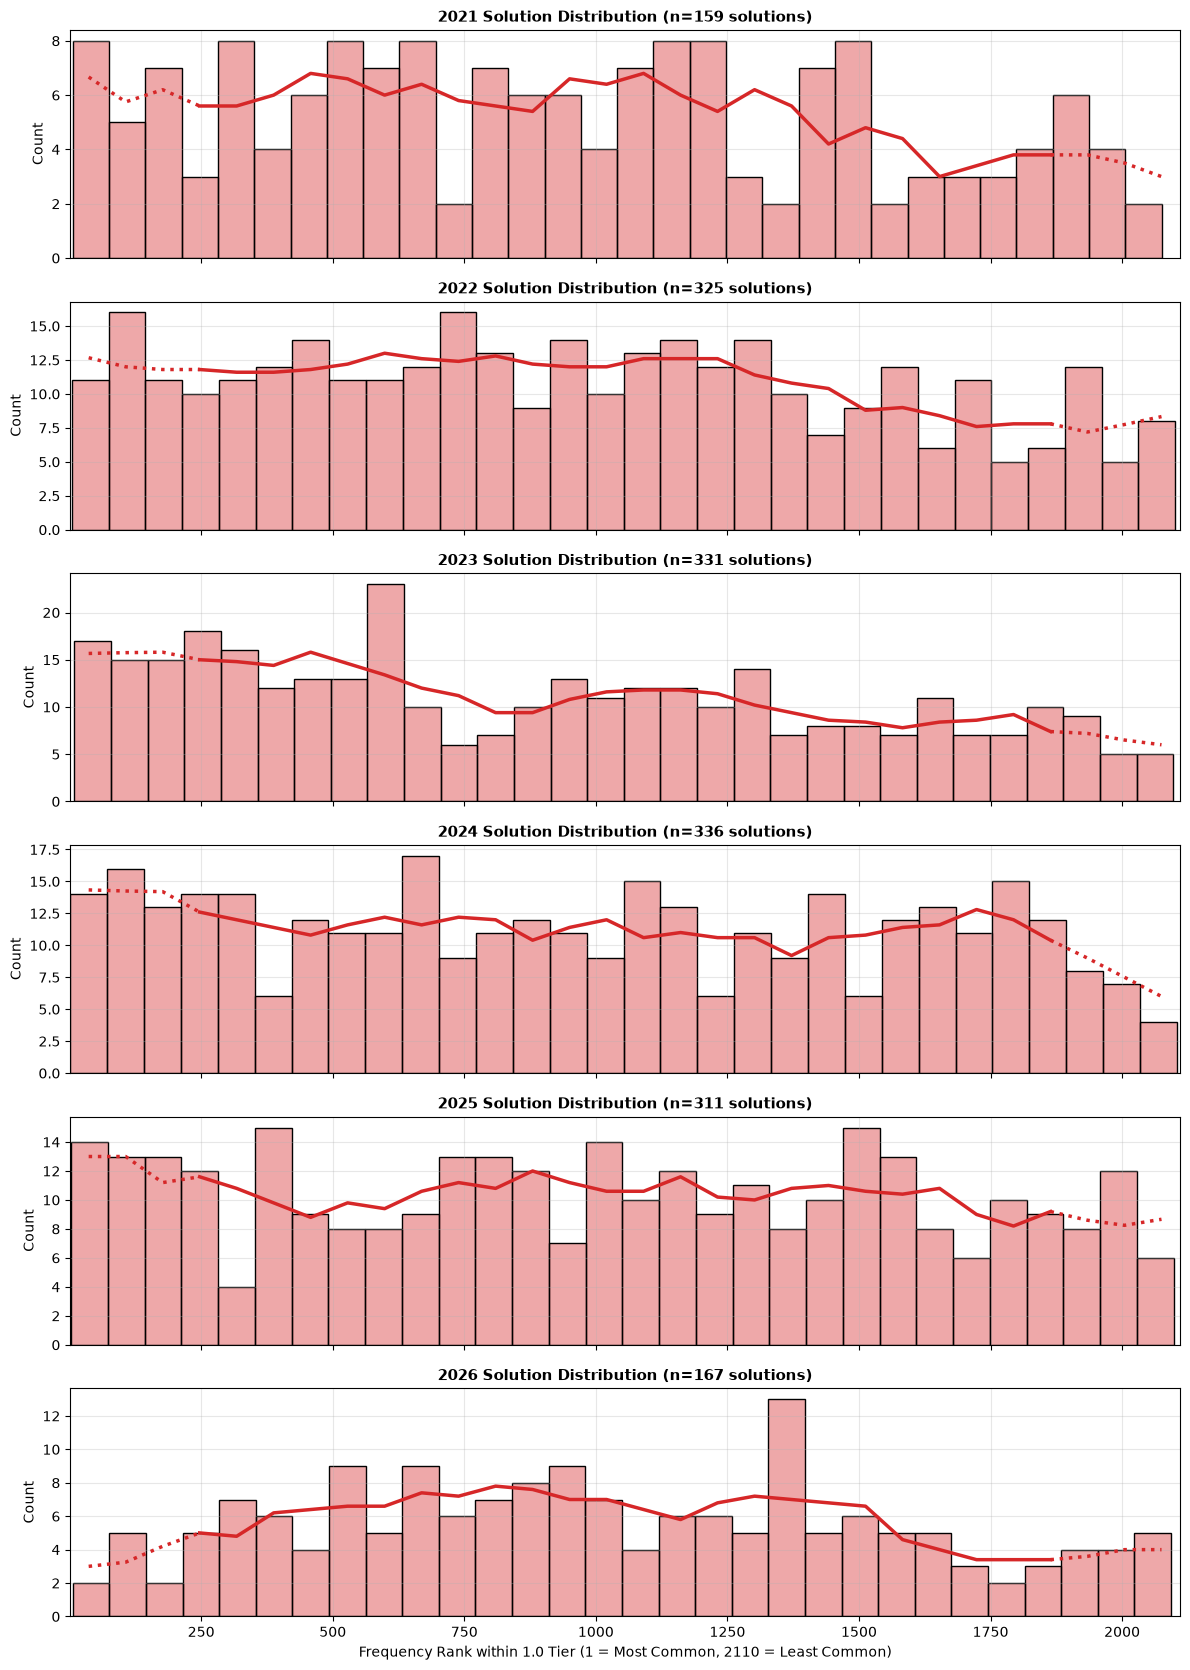

In [17]:
priors_words = df_priors.iloc[:, 0].astype(str).str.strip().str.lower()
priors_vals = pd.to_numeric(df_priors.iloc[:, 1], errors='coerce').fillna(0.0)
top_tier_words = set(priors_words[np.isclose(priors_vals, 1.0)])

# 2. Load heuristics and rank the 2,110 top-tier words
heuristics_df = pd.read_csv('../data/full_frequency_heuristics.csv')
heuristics_df['word'] = heuristics_df['word'].astype(str).str.strip().str.lower()

# Filter for the 2,110 words and rank by probability/stage_1_rank
top_tier_df = heuristics_df[heuristics_df['word'].isin(top_tier_words)].copy()

if 'stage_1_rank' in top_tier_df.columns:
    top_tier_df = top_tier_df.sort_values(by='stage_1_rank', ascending=True)
elif 'ranking_prob' in top_tier_df.columns:
    top_tier_df = top_tier_df.sort_values(by='ranking_prob', ascending=False)
else:
    top_tier_df = top_tier_df.sort_values(by='oof_predicted_prob', ascending=False)

# Assign internal tier rank from 1 (most frequent) to 2110 (least frequent)
top_tier_df['tier_rank'] = np.arange(1, len(top_tier_df) + 1)
rank_lookup = dict(zip(top_tier_df['word'], top_tier_df['tier_rank']))

# 3. Match historical solutions (res_df) through 2026
res_df_copy = res_df.copy()
res_df_copy['date'] = pd.to_datetime(res_df_copy['date'])
res_df_copy['year'] = res_df_copy['date'].dt.year

# Locate the word column in res_df
word_col = 'word' if 'word' in res_df_copy.columns else ('solution' if 'solution' in res_df_copy.columns else res_df_copy.columns[1])
res_df_copy['clean_word'] = res_df_copy[word_col].astype(str).str.strip().str.lower()

# Filter solutions that belong to the 1.0 tier
solutions_tier = res_df_copy[res_df_copy['clean_word'].isin(top_tier_words)].copy()
solutions_tier['tier_rank'] = solutions_tier['clean_word'].map(rank_lookup)

print(f"Total 1.0 Tier Words: {len(top_tier_df)}")
print(f"Total Solutions from 1.0 Tier (2021-2026): {len(solutions_tier)} / {len(res_df)}")

# 4. GRAPH 1: Overall Distribution (All Years Combined)
plt.figure(figsize=(12, 5))

# 1. Plot histogram without built-in KDE
sns.histplot(solutions_tier['tier_rank'], bins=30, color='tab:blue', edgecolor='black', alpha=0.6)

# 2. Calculate smooth rolling trend line on bin centers
counts, bin_edges = np.histogram(solutions_tier['tier_rank'], bins=30, range=(1, len(top_tier_df)))
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smooth_y = pd.Series(counts).rolling(window=5, center=True, min_periods=1).mean().values

# 3. Define boundary cuts to separate middle trend from boundary tails
left_cut, right_cut = 3, len(centers) - 3

# Solid line for main middle trend
plt.plot(centers[left_cut:right_cut], smooth_y[left_cut:right_cut], 
         color='tab:blue', linewidth=2.5, label='Middle Trend')

# Dotted lines continuing the trend through the end boundaries
plt.plot(centers[:left_cut + 1], smooth_y[:left_cut + 1], 
         color='tab:blue', linestyle=':', linewidth=2.5)
plt.plot(centers[right_cut - 1:], smooth_y[right_cut - 1:], 
         color='tab:blue', linestyle=':', linewidth=2.5)

plt.title('Overall Frequency Rank Distribution for 1.0 Prior Solutions (All Years 2021-2026)', fontsize=13, fontweight='bold')
plt.xlabel('Frequency Rank within 1.0 Tier (1 = Most Common, 2110 = Least Common)')
plt.ylabel('Number of Solutions')
plt.xlim(1, len(top_tier_df))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. GRAPH 2: Year-by-Year Breakdown
years = sorted(solutions_tier['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(12, 2.8 * len(years)), sharex=True)

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    year_data = solutions_tier[solutions_tier['year'] == year]
    
    # 1. Plot histogram without built-in KDE
    sns.histplot(year_data['tier_rank'], bins=30, ax=ax, color='tab:red', edgecolor='black', alpha=0.4)
    
    # 2. Calculate smooth rolling trend line on bin centers
    counts, bin_edges = np.histogram(year_data['tier_rank'], bins=30, range=(1, len(top_tier_df)))
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    smooth_y = pd.Series(counts).rolling(window=5, center=True, min_periods=1).mean().values
    
    # 3. Define boundary cuts to separate middle trend from boundary tails
    left_cut, right_cut = 3, len(centers) - 3
    
    # Solid line for main middle trend
    ax.plot(centers[left_cut:right_cut], smooth_y[left_cut:right_cut], 
            color='tab:red', linewidth=2.5, label='Middle Trend')
    
    # Dotted lines continuing the trend through the end boundaries
    ax.plot(centers[:left_cut + 1], smooth_y[:left_cut + 1], 
            color='tab:red', linestyle=':', linewidth=2.5)
    ax.plot(centers[right_cut - 1:], smooth_y[right_cut - 1:], 
            color='tab:red', linestyle=':', linewidth=2.5)
    
    ax.set_title(f'{year} Solution Distribution (n={len(year_data)} solutions)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlim(1, len(top_tier_df))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency Rank within 1.0 Tier (1 = Most Common, 2110 = Least Common)')
plt.tight_layout()
plt.show()